In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns



```
# This is formatted as code
```

# Data Initialisation

In [2]:
df = pd.read_csv('/content/AI_Startup_Analytics_Dataset.csv')
print(df.head(10))

       Company    Country       Industry  Founded  Employees  Funding_USD_M  \
0   AIStartup1  Singapore      Marketing     2016        500            220   
1   AIStartup2    Germany      Education     2017        305             65   
2   AIStartup3        USA  Cybersecurity     2021         31            210   
3   AIStartup4  Singapore      Marketing     2021        408            125   
4   AIStartup5        USA      Education     2023        183            165   
5   AIStartup6    Germany        Finance     2020        428            148   
6   AIStartup7    Germany  Cybersecurity     2016        370            145   
7   AIStartup8     Canada     Healthcare     2024        282             82   
8   AIStartup9      India   Productivity     2024        489             91   
9  AIStartup10      India      Marketing     2022        452             76   

   Monthly_Users  Subscription_USD AI_Model  Inference_Cost_USD  \
0         426278                50   Claude            26533.64

In [3]:
print(df.tail(10))

          Company    Country       Industry  Founded  Employees  \
290  AIStartup291     Canada  Cybersecurity     2019        353   
291  AIStartup292    Germany  Cybersecurity     2021        232   
292  AIStartup293         UK   Productivity     2021         26   
293  AIStartup294        USA        Finance     2026        409   
294  AIStartup295         UK      Marketing     2020         62   
295  AIStartup296        USA   Productivity     2021        267   
296  AIStartup297      India      Marketing     2020        114   
297  AIStartup298      India   Productivity     2018        243   
298  AIStartup299  Singapore     Healthcare     2020        369   
299  AIStartup300  Singapore   Productivity     2025        219   

     Funding_USD_M  Monthly_Users  Subscription_USD AI_Model  \
290             42         392704                10   Claude   
291            272         124877                30  Mistral   
292            259         340243                50    Llama   
293   

In [4]:

r,c = df.shape
print('The number of rows are:', r, 'and the number of columns are:', c)

The number of rows are: 300 and the number of columns are: 14


In [5]:
df.dtypes

,0
Company,object
Country,object
Industry,object
Founded,int64
Employees,int64
Funding_USD_M,int64
Monthly_Users,int64
Subscription_USD,int64
AI_Model,object
Inference_Cost_USD,float64


#Extracting Basic Info from the **Data**

```
# This is formatted as code
```



In [6]:
comp = df['Company'].unique()
print('The number of companies are: ', comp.size)

countries = df['Country'].unique()
print('The number of countries are: ', countries.size)

ind = df['Industry'].unique()
print('The number of industries are: ', ind.size)

model = df['AI_Model'].unique()
print('The models are: ', model)



The number of companies are:  300
The number of countries are:  6
The number of industries are:  6
The models are:  ['Claude' 'Gemini' 'Mistral' 'Llama' 'GPT']


# Data Cleaning

In [7]:

if df['Monthly_Revenue_USD'].max() > 1000:
    df['Monthly_Revenue_USD_M'] = df['Monthly_Revenue_USD'] / 1e6

if df['Monthly_Profit_USD'].max() > 1000:
    df['Monthly_Profit_USD_M'] = df['Monthly_Profit_USD'] / 1e6

if df['Inference_Cost_USD'].max() > 1000:
    df['Inference_Cost_USD_M'] = df['Inference_Cost_USD'] / 1e6

df.describe()

,Founded,Employees,Funding_USD_M,Monthly_Users,Subscription_USD,Inference_Cost_USD,Customer_Churn_pct,Customer_Satisfaction,Monthly_Revenue_USD,Monthly_Profit_USD,Monthly_Revenue_USD_M,Monthly_Profit_USD_M,Inference_Cost_USD_M
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,3.000000e+02,300.000000,300.000000,300.000000
mean,2020.673333,257.080000,154.573333,246770.043333,38.383333,24684.145733,10.474233,4.062100,8.097629e+05,6.459057e+05,0.809763,0.645906,0.024684
std,3.072146,148.112518,84.469927,143440.359488,29.092225,14041.252830,5.694578,0.549761,1.029326e+06,1.025416e+06,1.029326,1.025416,0.014041
min,2016.000000,8.000000,1.000000,2473.000000,10.000000,651.450000,1.070000,3.200000,2.736470e+03,-2.762755e+05,0.002736,-0.276275,0.000651
25%,2018.000000,129.750000,82.000000,127777.250000,20.000000,12382.020000,5.335000,3.560000,1.691644e+05,3.707633e+04,0.169164,0.037076,0.012382
50%,2021.000000,258.000000,153.500000,253855.000000,30.000000,23688.895000,10.300000,4.085000,4.276086e+05,2.878638e+05,0.427609,0.287864,0.023689
75%,2023.000000,391.250000,225.750000,372777.750000,50.000000,36389.132500,15.372500,4.562500,9.588297e+05,7.910666e+05,0.958830,0.791067,0.036389
max,2026.000000,500.000000,299.000000,499655.000000,99.000000,49877.700000,19.980000,4.990000,6.628637e+06,6.362260e+06,6.628637,6.362260,0.049878


# DATA INFERENCE

> Looking at some of the pressing questions asked by companies and replying with complete data proof and reasoning



# 1. Which industries are the most profitable?

Industry
Marketing        39.859611
Finance          39.081229
Healthcare       34.809008
Productivity     34.459774
Cybersecurity    25.789508
Education        19.772575
Name: Monthly_Profit_USD_M, dtype: float64


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Marketing'),
  Text(1, 0, 'Finance'),
  Text(2, 0, 'Healthcare'),
  Text(3, 0, 'Productivity'),
  Text(4, 0, 'Cybersecurity'),
  Text(5, 0, 'Education')])

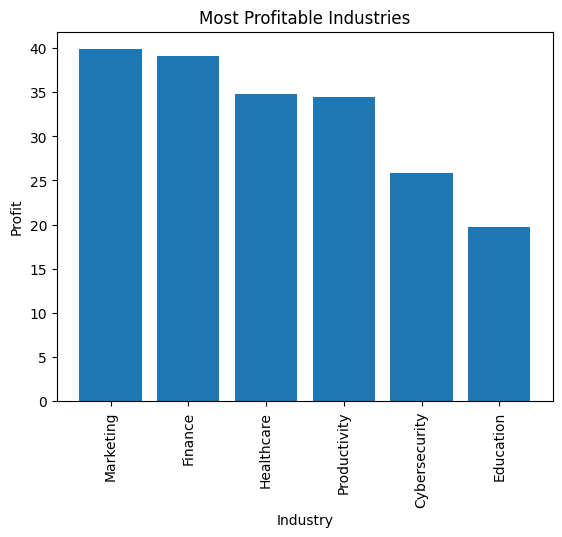

In [49]:
df[['Industry', 'Monthly_Profit_USD_M']].isnull().sum()
df.duplicated().sum()
df[['Industry', 'Monthly_Profit_USD_M']].describe()


ind_profit = df.groupby('Industry')['Monthly_Profit_USD_M'].sum()
s_ind_profit = (ind_profit.sort_values(ascending=False))
print(s_ind_profit)
plt.bar(s_ind_profit.index, s_ind_profit.values)
plt.title('Most Profitable Industries')
plt.xlabel('Industry')
plt.ylabel('Profit')
plt.xticks(rotation=90)

# 2. Does Funding Lead to Revenue?

> Add blockquote



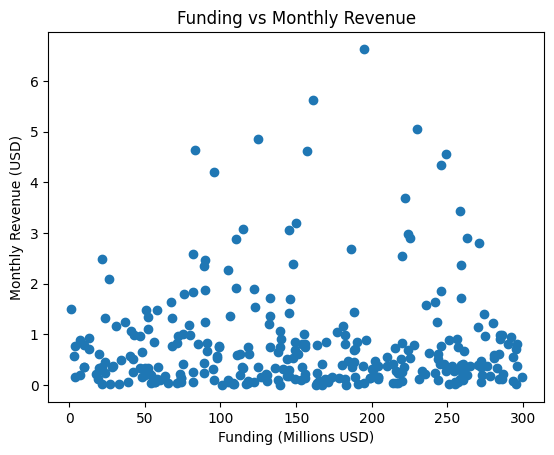

In [47]:
df[['Funding_USD_M', 'Monthly_Revenue_USD_M']].isnull().sum()
df.duplicated().sum()
df[['Funding_USD_M', 'Monthly_Revenue_USD_M']].describe()


plt.scatter(df['Funding_USD_M'], df['Monthly_Revenue_USD_M'])
plt.title('Funding vs Monthly Revenue')
plt.xlabel('Funding (Millions USD)')
plt.ylabel('Monthly Revenue (USD)')
plt.show()

[link text](https://)



---



```
# This is formatted as code
```

# 3. Does company size affect revenue?

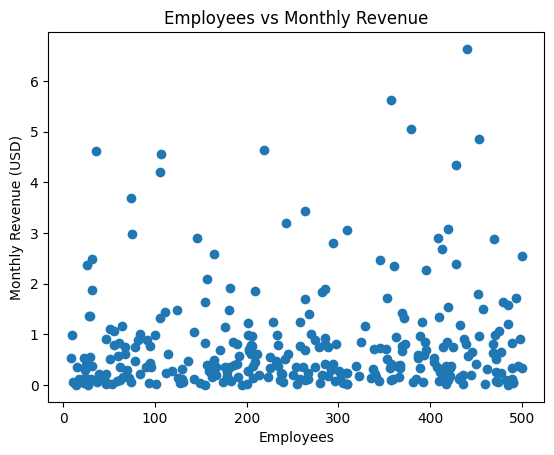

In [10]:
plt.scatter(df['Employees'], df['Monthly_Revenue_USD_M'])
plt.title('Employees vs Monthly Revenue')
plt.xlabel('Employees')
plt.ylabel('Monthly Revenue (USD)')
plt.show()

# 4. Does Higher Inference cost improve Customer Satisfaction?

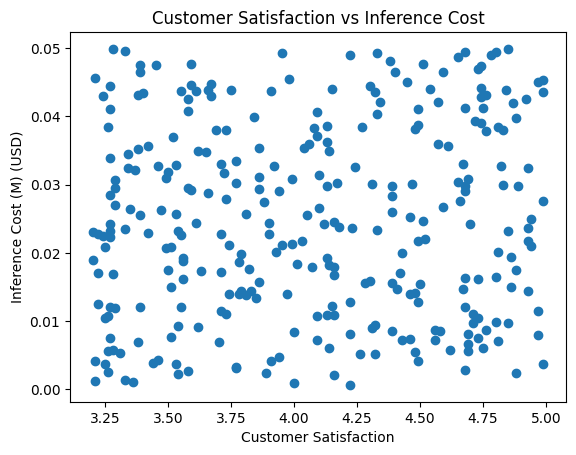

In [11]:
plt.scatter(df['Customer_Satisfaction'], df['Inference_Cost_USD_M'])
plt.title('Customer Satisfaction vs Inference Cost')
plt.xlabel('Customer Satisfaction')
plt.ylabel('Inference Cost (M) (USD)')
plt.show()

# 5. Which AI models generate the highest revenue and profit from these startups?

Text(0, 0.5, 'Profit (M)')

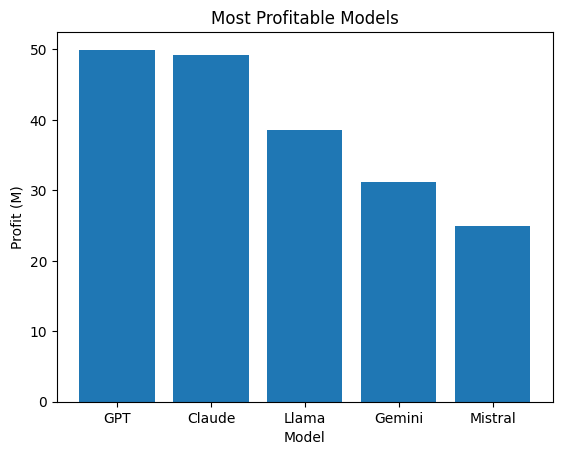

In [12]:
model_profit = df.groupby('AI_Model')['Monthly_Profit_USD_M'].sum()
s_model_profit = (model_profit.sort_values(ascending=False))

plt.title('Most Profitable Models')
plt.bar(s_model_profit.index, s_model_profit.values)
plt.xlabel('Model')
plt.ylabel('Profit (M)')

# 6. Is customer satisfaction related to customer churn?

In [16]:
#Using Correlation

cs_cc = df['Customer_Satisfaction'].corr(df['Customer_Churn_pct'])
print(cs_cc)

#From the output below, we can infer that there is a negative floating value, which means that increasing the customer satisfaction value will indicate that few people are likely to leave.

# 7. Does Company's Age Affect Financial Performance?

Correlation between profit and company age  -0.03258218896625496
Correlation between revnue and company age:  -0.03563624385657628


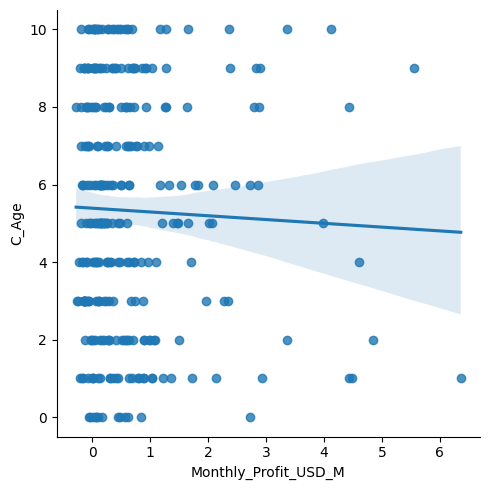

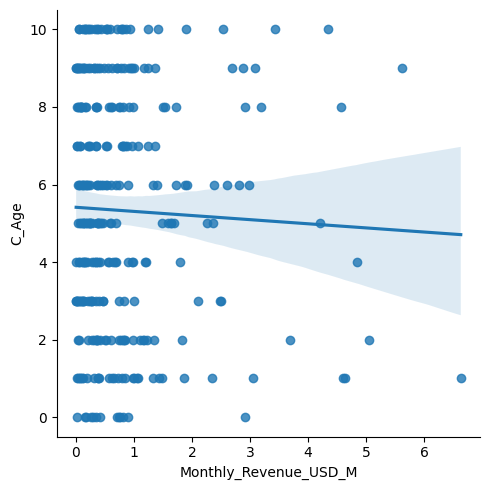

In [45]:
founding = df['Founded']
df['C_Age'] = datetime.now().year - founding

age_profit = df['Monthly_Profit_USD_M'].corr(df['C_Age'])
print('Correlation between profit and company age ', age_profit)

age_revenue = df['Monthly_Revenue_USD_M'].corr(df['C_Age'])
print('Correlation between revnue and company age: ', age_revenue)


sns.lmplot(x='Monthly_Profit_USD_M', y='C_Age', data=df)
plt.show()
sns.lmplot(x='Monthly_Revenue_USD_M', y='C_Age', data=df)
plt.show()


#To summarise the graph, the regression line is perfectly flat, that means that there is practically no relation between company age and the amount of revenue or profit it can or cannot earn. The data is very scattered and no reliable, or predictable pattern between these two variables.